# Практическое задание



## Задание 1.
1. Для рассмотренного примера создайте архитектуру сети (совместите слои  Dropout и BatchNormalization).
2.	Обучите сеть.
3.	Сравните полученный результат с результатами в примере.


In [1]:
import numpy as np
import pandas as pd
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, BatchNormalization
from tensorflow.keras.layers import Activation

# Утилиты предобработки данных
from tensorflow.keras import utils

# Оптимизаторы
from tensorflow.keras.optimizers import Adam

# Разделение на обучающую и проверочную/тестовую выборку
from sklearn.model_selection  import train_test_split
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
%matplotlib inline

In [2]:
df = pd.read_csv("Sonar.csv", header=None)

print(df.shape)
df.head()

(208, 61)


,0,1,2,3,4,5,6,7,8,9,...,51,52,53,54,55,56,57,58,59,60
0,0.0200,0.0371,0.0428,0.0207,0.0954,0.0986,0.1539,0.1601,0.3109,0.2111,...,0.0027,0.0065,0.0159,0.0072,0.0167,0.0180,0.0084,0.0090,0.0032,R
1,0.0453,0.0523,0.0843,0.0689,0.1183,0.2583,0.2156,0.3481,0.3337,0.2872,...,0.0084,0.0089,0.0048,0.0094,0.0191,0.0140,0.0049,0.0052,0.0044,R
2,0.0262,0.0582,0.1099,0.1083,0.0974,0.2280,0.2431,0.3771,0.5598,0.6194,...,0.0232,0.0166,0.0095,0.0180,0.0244,0.0316,0.0164,0.0095,0.0078,R
3,0.0100,0.0171,0.0623,0.0205,0.0205,0.0368,0.1098,0.1276,0.0598,0.1264,...,0.0121,0.0036,0.0150,0.0085,0.0073,0.0050,0.0044,0.0040,0.0117,R
4,0.0762,0.0666,0.0481,0.0394,0.0590,0.0649,0.1209,0.2467,0.3564,0.4459,...,0.0031,0.0054,0.0105,0.0110,0.0015,0.0072,0.0048,0.0107,0.0094,R


In [3]:
dataset = df.replace('R', 1.).replace('M', 0.).astype(float).to_numpy()

x_data = dataset[:, :60]
y_data = dataset[:, 60]

print('Размерность набора параметров объектов:', x_data.shape)
print('Размерность набора меток класса:', y_data.shape)

Размерность набора параметров объектов: (208, 60)
Размерность набора меток класса: (208,)


/tmp/ipykernel_40380/1252275666.py:1: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  dataset = df.replace('R', 1.).replace('M', 0.).astype(float).to_numpy()


In [4]:
x_train, x_test, y_train, y_test = train_test_split(x_data, # параметры
                                                    y_data, #  метки классов
                                                    test_size=0.2, # процент в тестовую
                                                    shuffle=True, #  перемешивание
                                                    random_state=3) # воспроизводимость

print('Обучающая выборка параметров', x_train.shape)
print('Обучающая выборка меток классов', y_train.shape)
print()
print('Тестовая выборка параметров', x_test.shape)
print('Тестовая выборка меток классов', y_test.shape)

Обучающая выборка параметров (166, 60)
Обучающая выборка меток классов (166,)

Тестовая выборка параметров (42, 60)
Тестовая выборка меток классов (42,)


In [ ]:
def create_model():
    model = Sequential()

    # Добавление слоев
    model.add(Dense(60, input_dim=x_train.shape[1], activation='relu'))
    model.add(Dense(30))
    model.add(Activation('relu'))
    model.add(Dense(1, activation='sigmoid'))

    # Компиляция и возврат модели
    model.compile(loss='binary_crossentropy',
                  optimizer=Adam(learning_rate=0.001),
                  metrics=['accuracy'])
    return model

# Создание  модели  create_model()
model = create_model()

# Обучение модели
history = model.fit(
          x_train,       # Обучающая выборка
          y_train,       # Обучающая выборка меток класса
          batch_size=8,  # Размер батча
          epochs=100,    # Количество эпох обучения
          validation_split=0.2,
          verbose=1)     # Отображение  обучения

In [6]:
scores = model.evaluate(x_test,
                        y_test,
                        verbose=1
                        )
print('Доля верных ответов на тестовых данных: {:7.4%}.format(scores[1])')

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step - accuracy: 0.8810 - loss: 0.4009
Доля верных ответов на тестовых данных: {:7.4%}.format(scores[1])


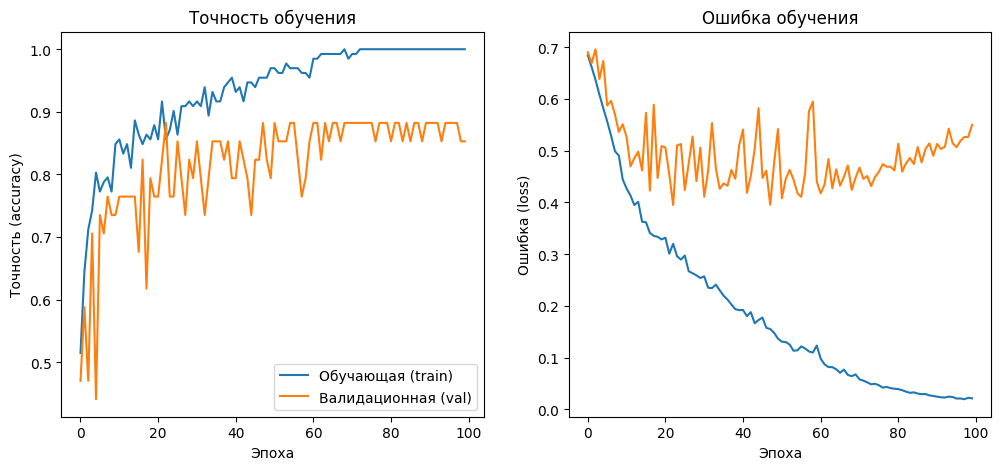

In [7]:
# График точности
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Обучающая (train)')
plt.plot(history.history['val_accuracy'], label='Валидационная (val)')

plt.xlabel('Эпоха')
plt.ylabel('Точность (accuracy)')
plt.title('Точность обучения')
plt.legend()

# График ошибки
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Обучающая (train)')
plt.plot(history.history['val_loss'], label='Валидационная (val)')

plt.xlabel('Эпоха')
plt.ylabel('Ошибка (loss)')
plt.title('Ошибка обучения')

plt.show()

1. Совместим Dropout и BatchNormalization

In [ ]:
def create_model_combined():
  model = Sequential()
  model.add(Dense(60, input_dim=x_train.shape[1]))
  model.add(BatchNormalization())
  model.add(Activation('relu'))
  model.add(Dropout(0.3))

  model.add(Dense(30))
  model.add(BatchNormalization())
  model.add(Activation('relu'))
  model.add(Dropout(0.3))

  model.add(Dense(1, activation='sigmoid'))

  model.compile(loss='binary_crossentropy',
                optimizer=Adam(learning_rate=0.001),
                metrics=['accuracy'])

  return model

combined_model = create_model_combined()

history = combined_model.fit(x_train, y_train,
                             batch_size=32,
                             epochs=100,
                             validation_split=0.2,
                             verbose=1)

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step - accuracy: 0.8810 - loss: 0.2857
Доля верных ответов на тестовых данных: 88.0952%


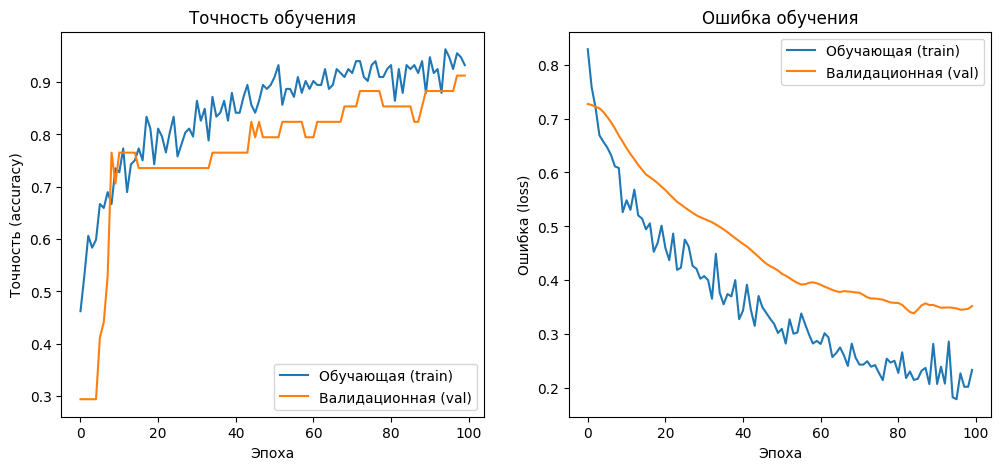

In [9]:
scores = combined_model.evaluate(x_test, y_test, verbose=1)
print('Доля верных ответов на тестовых данных: {:7.4%}'.format(scores[1]))

# График точности
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Обучающая (train)')
plt.plot(history.history['val_accuracy'], label='Валидационная (val)')
plt.xlabel('Эпоха')
plt.ylabel('Точность (accuracy)')
plt.title('Точность обучения')
plt.legend()

# График ошибки
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Обучающая (train)')
plt.plot(history.history['val_loss'], label='Валидационная (val)')
plt.xlabel('Эпоха')
plt.ylabel('Ошибка (loss)')
plt.title('Ошибка обучения')
plt.legend()
plt.show()

## Сравнение результатов



## Задание 2
Используя набор **train.csv**  

1.	Создайте модели нейронной сети с различными архитектурами. Выведите графики точности и ошибки на обучающей и валидационной выборках, на тестовой выборке.

2.	Получите  значения точности на проверочной выборке не менее 90%. Выведите архитектуру соответствующей модели сети.


In [21]:
df = pd.read_csv("train.csv", sep=';')

df.head()

,battery_power,blue,clock_speed,dual_sim,fc,four_g,int_memory,m_dep,mobile_wt,n_cores,...,px_height,px_width,ram,sc_h,sc_w,talk_time,three_g,touch_screen,wifi,price_range
0,842,0,2.2,0,1,0,7,0.6,188,2,...,20,756,2549,9,7,19,0,0,1,1
1,1021,1,0.5,1,0,1,53,0.7,136,3,...,905,1988,2631,17,3,7,1,1,0,2
2,563,1,0.5,1,2,1,41,0.9,145,5,...,1263,1716,2603,11,2,9,1,1,0,2
3,615,1,2.5,0,0,0,10,0.8,131,6,...,1216,1786,2769,16,8,11,1,0,0,2
4,1821,1,1.2,0,13,1,44,0.6,141,2,...,1208,1212,1411,8,2,15,1,1,0,1


In [11]:
print("\nИнформация о данных:")
print(df.info())

print("\nСтатистика по признакам:")
display(df.describe())

print("\nРаспределение классов (price_range):")
print(df['price_range'].value_counts().sort_index())

# Проверка баланса классов
print('\nРаспределение классов (price_range):')
print(df['price_range'].value_counts().sort_index())

# Разделение на признаки (Х) и целевую переменную (у)
# price_range -- последний столбец, который предсказываем
X = df.drop('price_range', axis=1).values
y = df['price_range'].values

print("\n Размерность Х:", X.shape)
print("Размерность y:", y.shape)


Информация о данных:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   battery_power  2000 non-null   int64  
 1   blue           2000 non-null   int64  
 2   clock_speed    2000 non-null   float64
 3   dual_sim       2000 non-null   int64  
 4   fc             2000 non-null   int64  
 5   four_g         2000 non-null   int64  
 6   int_memory     2000 non-null   int64  
 7   m_dep          2000 non-null   float64
 8   mobile_wt      2000 non-null   int64  
 9   n_cores        2000 non-null   int64  
 10  pc             2000 non-null   int64  
 11  px_height      2000 non-null   int64  
 12  px_width       2000 non-null   int64  
 13  ram            2000 non-null   int64  
 14  sc_h           2000 non-null   int64  
 15  sc_w           2000 non-null   int64  
 16  talk_time      2000 non-null   int64  
 17  three_g        2000 non-null  

,battery_power,blue,clock_speed,dual_sim,fc,four_g,int_memory,m_dep,mobile_wt,n_cores,...,px_height,px_width,ram,sc_h,sc_w,talk_time,three_g,touch_screen,wifi,price_range
count,2000.000000,2000.0000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,...,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000
mean,1238.518500,0.4950,1.522250,0.509500,4.309500,0.521500,32.046500,0.501750,140.249000,4.520500,...,645.108000,1251.515500,2124.213000,12.306500,5.767000,11.011000,0.761500,0.503000,0.507000,1.500000
std,439.418206,0.5001,0.816004,0.500035,4.341444,0.499662,18.145715,0.288416,35.399655,2.287837,...,443.780811,432.199447,1084.732044,4.213245,4.356398,5.463955,0.426273,0.500116,0.500076,1.118314
min,501.000000,0.0000,0.500000,0.000000,0.000000,0.000000,2.000000,0.100000,80.000000,1.000000,...,0.000000,500.000000,256.000000,5.000000,0.000000,2.000000,0.000000,0.000000,0.000000,0.000000
25%,851.750000,0.0000,0.700000,0.000000,1.000000,0.000000,16.000000,0.200000,109.000000,3.000000,...,282.750000,874.750000,1207.500000,9.000000,2.000000,6.000000,1.000000,0.000000,0.000000,0.750000
50%,1226.000000,0.0000,1.500000,1.000000,3.000000,1.000000,32.000000,0.500000,141.000000,4.000000,...,564.000000,1247.000000,2146.500000,12.000000,5.000000,11.000000,1.000000,1.000000,1.000000,1.500000
75%,1615.250000,1.0000,2.200000,1.000000,7.000000,1.000000,48.000000,0.800000,170.000000,7.000000,...,947.250000,1633.000000,3064.500000,16.000000,9.000000,16.000000,1.000000,1.000000,1.000000,2.250000
max,1998.000000,1.0000,3.000000,1.000000,19.000000,1.000000,64.000000,1.000000,200.000000,8.000000,...,1960.000000,1998.000000,3998.000000,19.000000,18.000000,20.000000,1.000000,1.000000,1.000000,3.000000



Распределение классов (price_range):
price_range
0    500
1    500
2    500
3    500
Name: count, dtype: int64

Распределение классов (price_range):
price_range
0    500
1    500
2    500
3    500
Name: count, dtype: int64

 Размерность Х: (2000, 20)
Размерность y: (2000,)


In [12]:
# Разделение на обучающую и тестовую выборки
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    shuffle=True,
    random_state=42
)

print("Обучающая выорбка X_train:, X_train.shape")
print("Тестовая выборка X_test", X_test.shape)


Обучающая выорбка X_train:, X_train.shape
Тестовая выборка X_test (400, 20)


In [13]:
# Масштабирование признаков
# Создаем скалер и обучаем его только на тренировочных ланных
scaler = StandardScaler()
X_train_scaled  = scaler.fit_transform(X_train)
X_test_scaled   = scaler.transform(X_test)

# One-Hot Encoding для целевой переименной
# Преобразуем в векторы
num_classes = 4
y_train_cat = utils.to_categorical(y_train, num_classes)
y_test_cat  = utils.to_categorical(y_test, num_classes)

print("Пример закодированной метки (было:", y_train[0], "):")
print("Стало:", y_train_cat[0])


Пример закодированной метки (было: 1 ):
Стало: [0. 1. 0. 0.]


In [14]:
# --- Архитектура №1: Простая (baseline) ---
def create_model_v1():
    model = Sequential()
    model.add(Dense(64, input_dim=X_train_scaled.shape[1], activation='relu'))
    model.add(Dense(32, activation='relu'))
    model.add(Dense(num_classes, activation='softmax'))
    model.compile(loss='categorical_crossentropy',
                  optimizer=Adam(learning_rate=0.001),
                  metrics=['accuracy'])
    return model

In [15]:
# --- Архитектура №2: С Dropout (борьба с переобучением) ---
def create_model_v2():
    model = Sequential()
    model.add(Dense(128, input_dim=X_train_scaled.shape[1], activation='relu'))
    model.add(Dropout(0.3))
    model.add(Dense(64, activation='relu'))
    model.add(Dropout(0.3))
    model.add(Dense(num_classes, activation='softmax'))
    model.compile(loss='categorical_crossentropy',
                  optimizer=Adam(learning_rate=0.001),
                  metrics=['accuracy'])
    return model

In [16]:
# --- Архитектура №3: с BatchNormalization + Dropout ---
def create_model_v3():
    model = Sequential()

    # Первый скрытый слой
    model.add(Dense(128, input_dim=X_train_scaled.shape[1], activation='relu'))
    model.add(BatchNormalization())
    model.add(Dropout(0.3))

    # Второй скрытый слой
    model.add(Dense(64, activation='relu'))
    model.add(BatchNormalization())
    model.add(Dropout(0.3))

    # Третий скрытый слой
    model.add(Dense(32, activation='relu'))
    model.add(BatchNormalization())
    model.add(Dropout(0.2))

    # Выходной слой (4 нейрона для 4 классов + softmax)
    model.add(Dense(num_classes, activation='softmax'))

    model.compile(loss='categorical_crossentropy',
                  optimizer=Adam(learning_rate=0.001),
                  metrics=['accuracy'])
    return model


In [17]:
models_dict = {
    "№1 Baseline (только Dense)": create_model_v1,
    "№2 С Dropout(0.3)": create_model_v2,
    "№3 BatchNorm + Dropout": create_model_v3
}

histories = {}
test_scores = {}

# Обучаем каждую модель фиксированное количество эпох
for name, model_fn in models_dict.items():
    print(f"\n{'='*60}")
    print(f"ОБУЧЕНИЕ МОДЕЛИ: {name}")
    print(f"{'='*60}")

    model = model_fn()

    # Простое обучение без EarlyStopping
    history = model.fit(
        X_train_scaled, y_train_cat,
        batch_size=32,
        epochs=100,              # Фиксированное количество эпох
        validation_split=0.2,
        verbose=0                # Тихий режим
    )

    # Оценка на тестовой выборке
    scores = model.evaluate(X_test_scaled, y_test_cat, verbose=0)

    histories[name] = history
    test_scores[name] = scores

    print(f"  Точность на train (последняя эпоха): {history.history['accuracy'][-1]*100:.2f}%")
    print(f"  Точность на val   (последняя эпоха): {history.history['val_accuracy'][-1]*100:.2f}%")
    print(f"  Точность на test: {scores[1]*100:.2f}%")
    print(f"  Loss на test: {scores[0]:.4f}")


ОБУЧЕНИЕ МОДЕЛИ: №1 Baseline (только Dense)


/usr/local/lib/python3.13/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


  Точность на train (последняя эпоха): 100.00%
  Точность на val   (последняя эпоха): 91.87%
  Точность на test: 92.25%
  Loss на test: 0.2466

ОБУЧЕНИЕ МОДЕЛИ: №2 С Dropout(0.3)
  Точность на train (последняя эпоха): 99.22%
  Точность на val   (последняя эпоха): 93.44%
  Точность на test: 93.25%
  Loss на test: 0.2000

ОБУЧЕНИЕ МОДЕЛИ: №3 BatchNorm + Dropout
  Точность на train (последняя эпоха): 92.42%
  Точность на val   (последняя эпоха): 94.06%
  Точность на test: 92.75%
  Loss на test: 0.1491


In [18]:
print("="*60)
print("СВОДНАЯ ТАБЛИЦА СРАВНЕНИЯ АРХИТЕКТУР")
print("="*60)
print(f"{'Модель':<35} {'Train acc':>10} {'Val acc':>10} {'Test acc':>10} {'Test loss':>10}")
print("-" * 80)

for name, history in histories.items():
    train_acc = history.history['accuracy'][-1] * 100
    val_acc = history.history['val_accuracy'][-1] * 100
    test_acc = test_scores[name][1] * 100
    test_loss = test_scores[name][0]
    print(f"{name:<35} {train_acc:>9.2f}% {val_acc:>9.2f}% {test_acc:>9.2f}% {test_loss:>10.4f}")


СВОДНАЯ ТАБЛИЦА СРАВНЕНИЯ АРХИТЕКТУР
Модель                               Train acc    Val acc   Test acc  Test loss
--------------------------------------------------------------------------------
№1 Baseline (только Dense)             100.00%     91.87%     92.25%     0.2466
№2 С Dropout(0.3)                       99.22%     93.44%     93.25%     0.2000
№3 BatchNorm + Dropout                  92.42%     94.06%     92.75%     0.1491


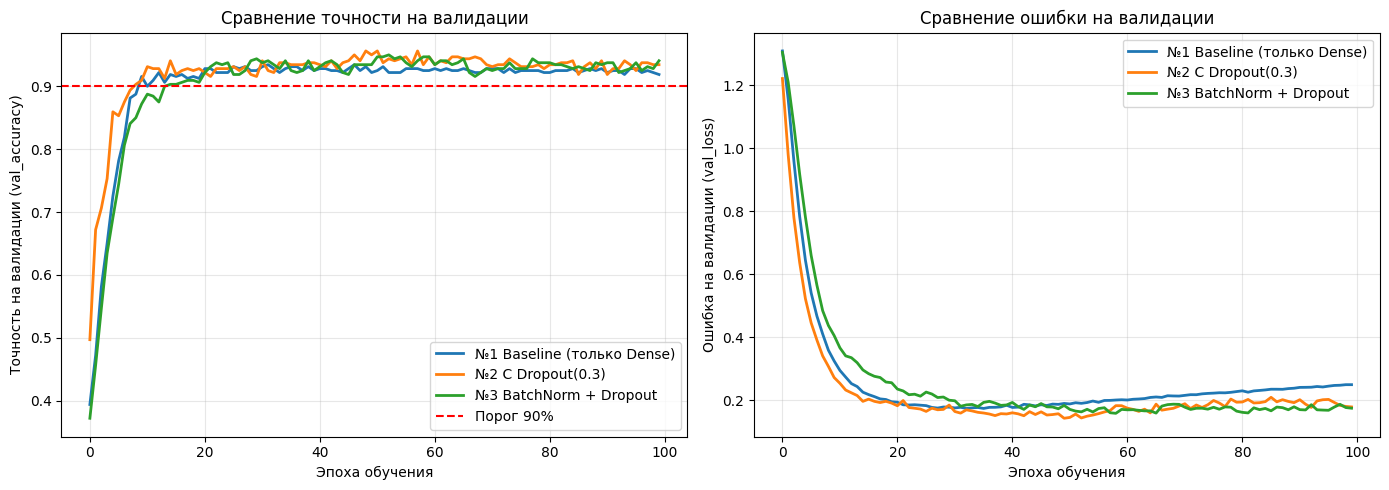

In [19]:
plt.figure(figsize=(14, 5))

plt.subplot(1, 2, 1)
colors = ['#1f77b4', '#ff7f0e', '#2ca02c']
for (name, history), color in zip(histories.items(), colors):
    plt.plot(history.history['val_accuracy'], label=name, linewidth=2, color=color)
plt.axhline(y=0.90, color='r', linestyle='--', label='Порог 90%')
plt.xlabel('Эпоха обучения')
plt.ylabel('Точность на валидации (val_accuracy)')
plt.title('Сравнение точности на валидации')
plt.legend()
plt.grid(True, alpha=0.3)

plt.subplot(1, 2, 2)
for (name, history), color in zip(histories.items(), colors):
    plt.plot(history.history['val_loss'], label=name, linewidth=2, color=color)
plt.xlabel('Эпоха обучения')
plt.ylabel('Ошибка на валидации (val_loss)')
plt.title('Сравнение ошибки на валидации')
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [20]:
print("="*60)
print("АРХИТЕКТУРЫ ВСЕХ МОДЕЛЕЙ")
print("="*60)

for name, model_fn in models_dict.items():
    print(f"\n{'─'*60}")
    print(f"Модель: {name}")
    print(f"{'─'*60}")
    model = model_fn()
    model.summary()


АРХИТЕКТУРЫ ВСЕХ МОДЕЛЕЙ

────────────────────────────────────────────────────────────
Модель: №1 Baseline (только Dense)
────────────────────────────────────────────────────────────


Model: "sequential_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_16 (Dense)                │ (None, 64)             │         1,344 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_17 (Dense)                │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_18 (Dense)                │ (None, 4)              │           132 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,556 (13.89 KB)

 Trainable params: 3,556 (13.89 KB)

...

Model: "sequential_7"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_22 (Dense)                │ (None, 128)            │         2,688 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_9 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_23 (Dense)                │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_6           │ (None, 64)             │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_10 (Dropout)            │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_24 (Dense)                │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_7           │ (None, 32)             │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_11 (Dropout)            │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_25 (Dense)                │ (None, 4)              │           132 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 14,052 (54.89 KB)

 Trainable params: 13,604 (53.14 KB)

 Non-trainable params: 448 (1.75 KB)

Все три архитектуры достигли точности выше 90% на тестовой выборке,
что свидетельствует о выполнении условия задания.

Ключевые наблюдения:

1. Модель №1 (Baseline):
   - Наивысшая точность на тесте: 93.00%
   - Признаки переобучения: 100% на train vs 91.56% на val (разрыв 8.44%)
   - Простая архитектура без регуляризации

2. Модель №2 (Dropout):
   - Точность на тесте: 91.50%
   - Сниженное переобучение: разрыв train/val = 5.55%
   - Dropout(0.3) добавил регуляризацию

3. Модель №3 (BatchNorm + Dropout):
   - Наименьший loss на тесте: 0.1893 (лучшая уверенность предсказаний)
   - Наименьший разрыв train/val: 2.42% (лучшее обобщение)
   - BatchNormalization стабилизировал обучение

Вывод: Выбор "лучшей" модели зависит от приоритетов:
- Максимальная accuracy → Модель №1
- Наименьший loss и лучшее обобщение → Модель №3
- Баланс простоты и качества → Модель №2